In [1]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 14.6 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.12.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which i

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, TensorDataset
from torchvision import transforms
from datasets import load_dataset
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
from PIL import Image
import traceback
import time

In [3]:
# Add CUDA debugging environment variable (makes CUDA calls synchronous, helps pinpoint errors)
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Clear cache if GPU is available
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Using device: cuda


In [4]:
!nvidia-smi

Tue Apr 15 12:50:34 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
def set_seed(seed=42):
    """Sets random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # Set CUDA seeds if available
    if torch.cuda.is_available():
        try:
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed) # for multi-GPU
            # Ensure deterministic behavior (can slow down training)
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False
        except RuntimeError as e:
            print(f"Warning: CUDA seed setting failed: {e}. Continuing without CUDA-specific seed.")

In [6]:
# Configuration Class
class Config:
    """Stores configuration parameters for the experiment."""
    # Dataset parameters
    dataset_name = "timm/mini-imagenet"
    img_size = 84  # Mini-ImageNet images are 84x84
    n_channels = 3

    # Few-shot learning setup
    n_ways = 5      # Number of classes in each task (must match ViT output)
    n_shots = 5     # Number of support examples per class
    n_query = 15    # Number of query examples per class for validation/testing within task

    # Diffusion model parameters
    diffusion_n_steps = 400     # Fewer steps for faster training/sampling
    beta_start = 1e-4
    beta_end = 0.02
    model_hidden_dim = 64       # Reduced U-Net hidden dim for memory
    model_channels = 32         # Reduced U-Net channels for memory
    model_attn_resolutions = [16] # Resolutions where attention is applied
    diffusion_dropout = 0.1
    diffusion_epochs = 30       # Reduced epochs for faster runs
    diffusion_batch_size = 8    # Reduced batch size for memory
    diffusion_lr = 1e-4
    n_synthetic_per_class = 20  # Number of synthetic images to generate per class

    # ViT parameters
    vit_patch_size = 4          # Patch size for ViT
    vit_dim = 128               # Reduced embedding dimension for memory
    vit_depth = 4               # Reduced number of transformer blocks
    vit_heads = 4               # Reduced number of attention heads
    vit_mlp_dim = 512           # Reduced MLP dimension in ViT blocks
    vit_dropout = 0.1

    # Training parameters
    vit_epochs = 50             # Reduced epochs for faster runs
    vit_batch_size = 8          # Reduced batch size for memory
    vit_lr = 1e-4
    weight_decay = 1e-4
    num_classes = 5             # Default number of classes for ViT (should match n_ways)

In [7]:
# Global cache for datasets to avoid reloading
cached_data = {
    'train_dataset': None,
    'val_dataset': None,
    'test_dataset': None,
    'n_classes': None,      # Total classes in original dataset
    'class_to_idx': None    # Mapping for original dataset
}

In [8]:
#-------------------------------------------------------------------
# 1. Data Loading and Preprocessing
#-------------------------------------------------------------------

class MiniImageNetDataset(Dataset):
    """Custom Dataset wrapper for HuggingFace Mini-ImageNet."""
    def __init__(self, dataset_split, transform=None):
        self.dataset = dataset_split
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        # Access data using dictionary keys
        item = self.dataset[idx]
        img = item['image']
        label = item['label']

        # Ensure image is PIL and in RGB format
        if not isinstance(img, Image.Image):
             # Assuming it might be numpy array or tensor, convert to PIL
             if isinstance(img, np.ndarray):
                 img = Image.fromarray(img)
             elif isinstance(img, torch.Tensor):
                 # Handle tensor conversion (assuming CHW or HWC)
                 if img.dim() == 3 and img.shape[0] == 3: # CHW
                     img = transforms.ToPILImage()(img)
                 elif img.dim() == 3 and img.shape[2] == 3: # HWC
                     img = Image.fromarray(img.numpy().astype(np.uint8))
                 elif img.dim() == 2: # Grayscale? Convert to RGB
                     img = Image.fromarray(img.numpy().astype(np.uint8)).convert('RGB')
                 else:
                     # Fallback or raise error for unexpected tensor shapes
                     print(f"Warning: Unexpected tensor shape {img.shape} at index {idx}. Trying to convert.")
                     try:
                         img = transforms.ToPILImage()(img) # Attempt conversion
                     except Exception as e:
                         print(f"Error converting tensor to PIL: {e}. Returning placeholder.")
                         # Return a placeholder or raise error
                         return torch.zeros(Config.n_channels, Config.img_size, Config.img_size), -1 # Placeholder

        # Convert non-RGB PIL images to RGB
        if img.mode != 'RGB':
            img = img.convert('RGB')

        # Apply transformations if provided
        if self.transform:
            img = self.transform(img)

        # Return image tensor and integer label
        return img, int(label)

class SafeSubset(Subset):
    """
    A custom Subset class that ensures labels are properly converted to correct dtype.
    Needed if the underlying dataset returns labels in a non-standard format.
    """
    def __getitem__(self, idx):
        # Get data from the original dataset using the mapped index
        data, label = self.dataset[self.indices[idx]]
        # Ensure label is a standard Python integer
        return data, int(label)

def load_mini_imagenet():
    """Loads the Mini-ImageNet dataset using HuggingFace datasets, with caching."""
    # Check cache first
    if cached_data['train_dataset'] is not None:
        print("Using cached datasets...")
        return (cached_data['train_dataset'],
                cached_data['val_dataset'],
                cached_data['test_dataset'],
                cached_data['n_classes'],
                cached_data['class_to_idx'])

    print("Loading and preprocessing Mini-ImageNet data...")
    try:
        # Load the dataset from HuggingFace Hub
        dataset = load_dataset(Config.dataset_name, trust_remote_code=True) # Added trust_remote_code=True if needed
    except Exception as e:
        print(f"Error loading dataset '{Config.dataset_name}': {e}")
        print("Please ensure the dataset name is correct and you have internet access.")
        raise

    # Define image transformations
    # Train transform includes augmentation
    train_transform = transforms.Compose([
        transforms.Resize((Config.img_size, Config.img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
        transforms.ToTensor(), # Converts PIL Image (H x W x C) [0, 255] to FloatTensor (C x H x W) [0.0, 1.0]
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Standard ImageNet normalization
    ])

    # Test transform only resizes, converts to tensor, and normalizes
    test_transform = transforms.Compose([
        transforms.Resize((Config.img_size, Config.img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Create Dataset instances for each split
    train_dataset = MiniImageNetDataset(dataset['train'], transform=train_transform)
    val_dataset = MiniImageNetDataset(dataset['validation'], transform=test_transform)
    test_dataset = MiniImageNetDataset(dataset['test'], transform=test_transform)

    # Extract class information from the training set
    try:
        all_labels = [item['label'] for item in dataset['train']]
        all_classes = sorted(list(set(all_labels)))
        n_classes = len(all_classes)
        class_to_idx = {cls_name: idx for idx, cls_name in enumerate(all_classes)}
        print(f"Found {n_classes} unique classes in the original training set.")
    except Exception as e:
        print(f"Error extracting class information: {e}")
        # Fallback if label structure is different
        n_classes = -1
        class_to_idx = {}


    # Cache the loaded data
    cached_data['train_dataset'] = train_dataset
    cached_data['val_dataset'] = val_dataset
    cached_data['test_dataset'] = test_dataset
    cached_data['n_classes'] = n_classes
    cached_data['class_to_idx'] = class_to_idx

    print("Dataset loading complete.")
    return train_dataset, val_dataset, test_dataset, n_classes, class_to_idx

class FewShotSubset(Dataset):
    """
    A custom dataset subset specifically for few-shot tasks.
    It takes a list of (original_index, new_label, original_label) tuples
    and returns the data corresponding to original_index but with new_label.
    """
    def __init__(self, original_dataset, indices_and_labels):
        self.original_dataset = original_dataset
        # Store list of tuples: (original_dataset_index, remapped_few_shot_label, original_label)
        self.indices_and_labels = indices_and_labels
        print(f"FewShotSubset created with {len(indices_and_labels)} samples.")
        # Optional: Validate indices are within bounds of original_dataset
        max_original_idx = max(idx for idx, _, _ in indices_and_labels) if indices_and_labels else -1
        if max_original_idx >= len(original_dataset):
             raise ValueError(f"Index out of bounds in FewShotSubset: Max index {max_original_idx} >= Dataset length {len(original_dataset)}")


    def __getitem__(self, idx):
        # Get the mapping information for the requested index
        original_idx, new_label, _ = self.indices_and_labels[idx]
        # Retrieve the data (image) from the original dataset using the original index
        data, _ = self.original_dataset[original_idx] # We ignore the original label here
        # Return the data paired with the *new* remapped label
        return data, int(new_label) # Ensure label is int

    def __len__(self):
        # The length of the subset is the number of mappings provided
        return len(self.indices_and_labels)

In [9]:
#-------------------------------------------------------------------
# 2. Few-Shot Learning Setup
#-------------------------------------------------------------------

class FewShotDataset:
    """Handles the creation of few-shot classification tasks (support and query sets)."""
    def __init__(self, dataset, n_ways, n_shots, n_query):
        self.dataset = dataset
        self.n_ways = n_ways
        self.n_shots = n_shots
        self.n_query = n_query

        # Organize dataset indices by their original class label
        self.samples_by_class = {}
        print("Organizing samples by class...")
        for idx in tqdm(range(len(dataset))):
            try:
                _, label = dataset[idx] # Get label for each item
                label = int(label) # Ensure label is int
                if label not in self.samples_by_class:
                    self.samples_by_class[label] = []
                self.samples_by_class[label].append(idx)
            except Exception as e:
                print(f"Warning: Could not process item at index {idx}. Error: {e}. Skipping.")
                continue # Skip problematic items

        self.classes = sorted(list(self.samples_by_class.keys()))
        print(f"Found {len(self.classes)} classes with samples.")

        # Check if we have enough samples per class for the task setup
        for label, indices in self.samples_by_class.items():
            if len(indices) < (n_shots + n_query):
                print(f"Warning: Class {label} only has {len(indices)} samples, "
                      f"less than required n_shots({n_shots}) + n_query({n_query}) = {n_shots + n_query}.")


    def create_few_shot_task(self):
        """Creates a single N-way, K-shot task with support and query sets."""
        support_samples = [] # List of (original_index, new_label, original_label)
        query_samples = []   # List of (original_index, new_label, original_label)

        # Select N classes randomly from available classes
        valid_classes = [cls for cls, indices in self.samples_by_class.items() if len(indices) >= (self.n_shots + self.n_query)]
        if len(valid_classes) < self.n_ways:
             raise ValueError(f"Not enough classes ({len(valid_classes)}) with sufficient samples ({self.n_shots + self.n_query}) "
                              f"to create a {self.n_ways}-way task.")

        selected_classes = random.sample(valid_classes, self.n_ways)

        # For each selected class, sample K support and Q query examples
        for class_idx, original_label in enumerate(selected_classes):
            # Get all sample indices for this original class
            class_sample_indices = self.samples_by_class[original_label]

            # Randomly select K+Q samples without replacement
            selected_indices = random.sample(class_sample_indices, self.n_shots + self.n_query)

            # Assign the *new* sequential label (0 to N-1)
            new_label = class_idx

            # Add K samples to support set
            support_samples.extend([(idx, new_label, original_label) for idx in selected_indices[:self.n_shots]])
            # Add Q samples to query set
            query_samples.extend([(idx, new_label, original_label) for idx in selected_indices[self.n_shots:]])

        # Return the lists of mappings and the original classes selected for this task
        return support_samples, query_samples, selected_classes

    def create_fixed_few_shot_dataset(self, num_tasks=1):
        """Creates a fixed set of few-shot tasks for consistent experiments."""
        all_support_sets = []
        all_query_sets = []
        all_original_classes = []

        print(f"Creating {num_tasks} few-shot task(s)...")
        for i in range(num_tasks):
            try:
                support, query, selected_classes = self.create_few_shot_task()
                all_support_sets.append(support)
                all_query_sets.append(query)
                all_original_classes.append(selected_classes)
                print(f"  Task {i+1}: Created with classes {selected_classes}")
            except ValueError as e:
                print(f"Error creating task {i+1}: {e}")
                # Decide whether to stop or continue
                raise # Stop if any task fails

        return all_support_sets, all_query_sets, all_original_classes

def create_few_shot_loaders(original_dataset, support_indices_and_labels, query_indices_and_labels, batch_size):
    """
    Creates DataLoaders for the support and query sets using FewShotSubset.
    Args:
        original_dataset: The full dataset (e.g., train_dataset).
        support_indices_and_labels: List of (orig_idx, new_label, orig_label) for support set.
        query_indices_and_labels: List of (orig_idx, new_label, orig_label) for query set.
        batch_size: Batch size for the DataLoaders.
    Returns:
        support_loader, query_loader, support_labels (new), query_labels (new),
        support_orig_labels, query_orig_labels
    """
    print("Creating DataLoaders for few-shot task...")
    # Create FewShotSubset instances which handle the label remapping
    support_set = FewShotSubset(original_dataset, support_indices_and_labels)
    query_set = FewShotSubset(original_dataset, query_indices_and_labels)

    # Create DataLoaders
    support_loader = DataLoader(support_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    query_loader = DataLoader(query_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    # Extract labels for reference (optional, but useful for checks)
    support_new_labels = [int(new_label) for _, new_label, _ in support_indices_and_labels]
    query_new_labels = [int(new_label) for _, new_label, _ in query_indices_and_labels]
    support_orig_labels = [orig_label for _, _, orig_label in support_indices_and_labels]
    query_orig_labels = [orig_label for _, _, orig_label in query_indices_and_labels]

    print(f"Support loader: {len(support_set)} samples, Query loader: {len(query_set)} samples.")
    # Sanity check labels
    if support_new_labels:
        print(f"  Support set new labels range: [{min(support_new_labels)}, {max(support_new_labels)}]")
    if query_new_labels:
        print(f"  Query set new labels range: [{min(query_new_labels)}, {max(query_new_labels)}]")

    return support_loader, query_loader, support_new_labels, query_new_labels, support_orig_labels, query_orig_labels

In [10]:
#-------------------------------------------------------------------
# 3. Diffusion Model Implementation (U-Net based)
#-------------------------------------------------------------------

def get_timestep_embedding(timesteps, embedding_dim):
    """
    Creates sinusoidal positional embeddings for timesteps.
    From Fairseq implementation.
    Args:
        timesteps: 1-D Tensor of N indices (batch size).
        embedding_dim: The dimension of the embedding vector.
    Returns:
        [N x embedding_dim] Tensor of positional embeddings.
    """
    assert len(timesteps.shape) == 1, "Timesteps should be a 1D tensor"

    half_dim = embedding_dim // 2
    # Scale factor for frequency calculation
    emb = np.log(10000) / (half_dim - 1)
    # Create frequency values
    emb = torch.exp(torch.arange(half_dim, dtype=torch.float32, device=timesteps.device) * -emb)
    # Calculate embeddings: timesteps * frequencies
    emb = timesteps.float()[:, None] * emb[None, :]
    # Concatenate sin and cos components
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)

    # Handle odd embedding dimensions by padding with zeros
    if embedding_dim % 2 == 1:
        emb = F.pad(emb, (0, 1)) # Pad last dimension

    assert emb.shape == (timesteps.shape[0], embedding_dim), "Output embedding shape mismatch"
    return emb

class ResidualBlock(nn.Module):
    """Residual block with GroupNorm, SiLU, Conv, Dropout."""
    def __init__(self, in_channels, out_channels, dropout=0.1, time_emb_dim=None):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels

        # First part of the block
        self.norm1 = nn.GroupNorm(32, in_channels)
        self.act1 = nn.SiLU()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

        # Optional time embedding projection
        self.time_mlp = None
        if time_emb_dim is not None:
            self.time_mlp = nn.Sequential(
                nn.SiLU(),
                nn.Linear(time_emb_dim, out_channels)
            )

        # Second part of the block
        self.norm2 = nn.GroupNorm(32, out_channels)
        self.act2 = nn.SiLU()
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

        # Shortcut connection (if channels change)
        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x, time_emb=None):
        h = x # Store input for shortcut

        # First part
        h = self.norm1(h)
        h = self.act1(h)
        h = self.conv1(h)

        # Add time embedding if provided
        if self.time_mlp is not None and time_emb is not None:
            time_cond = self.time_mlp(time_emb)
            # Add broadcasted time embedding (B, C) -> (B, C, 1, 1)
            h = h + time_cond.unsqueeze(-1).unsqueeze(-1)

        # Second part
        h = self.norm2(h)
        h = self.act2(h)
        h = self.dropout(h)
        h = self.conv2(h)

        # Add shortcut connection
        return h + self.shortcut(x)

class AttentionBlock(nn.Module):
    """Self-attention block."""
    def __init__(self, channels, num_heads=4):
        super().__init__()
        assert channels % num_heads == 0, "Channels must be divisible by num_heads"
        self.channels = channels
        self.num_heads = num_heads
        self.head_dim = channels // num_heads
        self.scale = self.head_dim ** -0.5

        self.norm = nn.GroupNorm(32, channels)
        # Combine Q, K, V projections into one linear layer for efficiency
        self.qkv = nn.Conv2d(channels, channels * 3, kernel_size=1)
        # Output projection
        self.proj_out = nn.Conv2d(channels, channels, kernel_size=1)

    def forward(self, x):
        B, C, H, W = x.shape
        residual = x # Store for residual connection

        # Normalize and project to Q, K, V
        h = self.norm(x)
        qkv = self.qkv(h)

        # Split Q, K, V and rearrange for multi-head attention
        # (B, 3*C, H, W) -> (B, 3*num_heads, head_dim, H*W) -> 3 * (B, num_heads, H*W, head_dim)
        qkv = qkv.reshape(B, self.num_heads, self.head_dim * 3, H * W).permute(0, 1, 3, 2)
        q, k, v = qkv.chunk(3, dim=-1) # Split along the head_dim dimension

        # Calculate attention scores (scaled dot-product)
        # (B, num_heads, H*W, head_dim) @ (B, num_heads, head_dim, H*W) -> (B, num_heads, H*W, H*W)
        attn_scores = torch.matmul(q, k.transpose(-2, -1)) * self.scale
        attn_probs = F.softmax(attn_scores, dim=-1)

        # Apply attention weights to values
        # (B, num_heads, H*W, H*W) @ (B, num_heads, H*W, head_dim) -> (B, num_heads, H*W, head_dim)
        attn_output = torch.matmul(attn_probs, v)

        # Rearrange back to original shape (B, C, H, W)
        # (B, num_heads, H*W, head_dim) -> (B, H*W, num_heads, head_dim) -> (B, H*W, C) -> (B, C, H, W)
        attn_output = attn_output.permute(0, 2, 1, 3).reshape(B, H * W, C)
        attn_output = attn_output.transpose(1, 2).reshape(B, C, H, W)

        # Project output and add residual connection
        out = self.proj_out(attn_output)
        return residual + out

class DownBlock(nn.Module):
    """Downsampling block for U-Net (ResBlock -> Optional Attention -> Downsample)."""
    def __init__(self, in_channels, out_channels, time_emb_dim, dropout=0.1, use_attention=False):
        super().__init__()
        self.resblock = ResidualBlock(in_channels, out_channels, dropout, time_emb_dim)
        self.attn = AttentionBlock(out_channels) if use_attention else nn.Identity()
        # Downsample using strided convolution
        self.downsample = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=2, padding=1)

    def forward(self, x, time_emb):
        x = self.resblock(x, time_emb)
        x = self.attn(x)
        # Store output before downsampling for skip connection
        skip_output = x
        x = self.downsample(x)
        return x, skip_output # Return downsampled output and skip connection

class UpBlock(nn.Module):
    """Upsampling block for U-Net (Upsample -> Concat Skip -> ResBlock -> Optional Attention)."""
    def __init__(self, in_channels, out_channels, time_emb_dim, dropout=0.1, use_attention=False):
        super().__init__()
        # Upsample using nearest neighbor + conv
        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        )
        # Residual block takes concatenated input (skip + upsampled)
        self.resblock = ResidualBlock(out_channels * 2, out_channels, dropout, time_emb_dim)
        self.attn = AttentionBlock(out_channels) if use_attention else nn.Identity()

    def forward(self, x, skip_x, time_emb):
        # Upsample the input from the lower layer
        x = self.upsample(x)
        # Concatenate with the skip connection from the corresponding DownBlock
        x = torch.cat([skip_x, x], dim=1) # Concatenate along channel dimension
        # Pass through ResBlock and Attention
        x = self.resblock(x, time_emb)
        x = self.attn(x)
        return x

class UNet(nn.Module):
    """
    U-Net architecture for noise prediction in the diffusion model.
    Based on DDPM (Denoising Diffusion Probabilistic Models).
    """
    def __init__(self,
                 in_channels=3,
                 model_channels=64, # Base channel count, scales up/down
                 out_channels=3,    # Usually same as in_channels (predicting noise)
                 channel_mult=(1, 2, 4, 8), # Multipliers for channels at each resolution level
                 attention_resolutions=(16, 8), # Image resolutions where attention is applied
                 num_res_blocks=2,          # Number of residual blocks per level
                 dropout=0.1,
                 time_emb_dim_factor=4):    # Factor to multiply model_channels for time embedding dim
        super().__init__()

        self.model_channels = model_channels
        time_emb_dim = model_channels * time_emb_dim_factor

        # --- Time Embedding ---
        self.time_embedding = nn.Sequential(
            # Project timestep embedding to a higher dimension
            nn.Linear(model_channels, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        # --- Initial Convolution ---
        self.init_conv = nn.Conv2d(in_channels, model_channels, kernel_size=3, padding=1)

        # --- Downsampling Path (Encoder) ---
        self.down_blocks = nn.ModuleList()
        current_channels = model_channels
        current_res = Config.img_size # Assuming square images
        levels = len(channel_mult)

        for i in range(levels):
            out_ch = model_channels * channel_mult[i]
            for _ in range(num_res_blocks):
                use_attention = current_res in attention_resolutions
                self.down_blocks.append(ResidualBlock(
                    current_channels, out_ch, dropout, time_emb_dim=time_emb_dim
                ))
                if use_attention:
                    self.down_blocks.append(AttentionBlock(out_ch))
                current_channels = out_ch # Update channels for next block

            # Add downsampling layer unless it's the last level
            if i != levels - 1:
                self.down_blocks.append(Downsample(current_channels))
                current_res //= 2

        # --- Middle Path ---
        self.middle_block = nn.Sequential(
            ResidualBlock(current_channels, current_channels, dropout, time_emb_dim=time_emb_dim),
            AttentionBlock(current_channels),
            ResidualBlock(current_channels, current_channels, dropout, time_emb_dim=time_emb_dim)
        )

        # --- Upsampling Path (Decoder) ---
        self.up_blocks = nn.ModuleList()
        for i in reversed(range(levels)):
            in_ch_mult = channel_mult[i]
            out_ch_mult = channel_mult[i-1] if i > 0 else channel_mult[0] # Handle first level

            # Add upsampling layer unless it's the first level (innermost)
            if i != levels - 1:
                 self.up_blocks.append(Upsample(current_channels))
                 current_res *= 2

            for j in range(num_res_blocks + 1): # +1 to account for skip connection input
                use_attention = current_res in attention_resolutions
                # Input channels = current + skip connection channels
                skip_channels = model_channels * channel_mult[i] # Channels from corresponding down level
                block_in_channels = current_channels + skip_channels if j == 0 else model_channels * out_ch_mult

                self.up_blocks.append(ResidualBlock(
                    block_in_channels, model_channels * out_ch_mult, dropout, time_emb_dim=time_emb_dim
                ))
                if use_attention:
                    self.up_blocks.append(AttentionBlock(model_channels * out_ch_mult))

            current_channels = model_channels * out_ch_mult


        # --- Output Head ---
        self.out = nn.Sequential(
            nn.GroupNorm(32, model_channels),
            nn.SiLU(),
            # Final convolution maps back to the original number of image channels
            nn.Conv2d(model_channels, out_channels, kernel_size=3, padding=1)
        )

    def forward(self, x, t):
        """
        Args:
            x: Input noisy image tensor (B, C, H, W).
            t: Timestep tensor (B,).
        Returns:
            Predicted noise tensor (B, C, H, W).
        """
        # 1. Get timestep embedding
        # First, get sinusoidal embedding based on model_channels
        time_emb_sin = get_timestep_embedding(t, self.model_channels)
        # Then, project it using the learned MLP
        time_emb = self.time_embedding(time_emb_sin) # Shape: (B, time_emb_dim)

        # 2. Initial convolution
        h = self.init_conv(x)
        skips = [h] # Store skip connections

        # 3. Downsampling path
        down_block_idx = 0
        while isinstance(self.down_blocks[down_block_idx], ResidualBlock) or isinstance(self.down_blocks[down_block_idx], AttentionBlock):
             block = self.down_blocks[down_block_idx]
             if isinstance(block, ResidualBlock):
                 h = block(h, time_emb)
             else: # AttentionBlock or Downsample
                 h = block(h)
             skips.append(h)
             down_block_idx += 1
             if down_block_idx >= len(self.down_blocks): break # Exit if no more down blocks

             # Handle Downsample layer separately if it exists
             if isinstance(self.down_blocks[down_block_idx], Downsample):
                 h = self.down_blocks[down_block_idx](h)
                 skips.append(h) # Store after downsampling too? Check original implementation
                 down_block_idx += 1
                 if down_block_idx >= len(self.down_blocks): break


        # 4. Middle path
        h = self.middle_block[0](h, time_emb) # First ResBlock
        h = self.middle_block[1](h)          # Attention
        h = self.middle_block[2](h, time_emb) # Second ResBlock

        # 5. Upsampling path
        up_block_idx = 0
        while up_block_idx < len(self.up_blocks):
            # Handle Upsample layer first if it exists
            if isinstance(self.up_blocks[up_block_idx], Upsample):
                h = self.up_blocks[up_block_idx](h)
                up_block_idx += 1
                if up_block_idx >= len(self.up_blocks): break # Should not happen if structure is correct

            # Now handle ResBlocks and Attention, incorporating skip connections
            skip_h = skips.pop() # Get corresponding skip connection
            h = torch.cat([h, skip_h], dim=1) # Concatenate

            # Process through ResBlock(s) and Attention for this level
            num_blocks_this_level = 0 # Count how many Res/Attn blocks follow
            temp_idx = up_block_idx
            while temp_idx < len(self.up_blocks) and (isinstance(self.up_blocks[temp_idx], ResidualBlock) or isinstance(self.up_blocks[temp_idx], AttentionBlock)):
                num_blocks_this_level += 1
                temp_idx += 1

            for _ in range(num_blocks_this_level):
                block = self.up_blocks[up_block_idx]
                if isinstance(block, ResidualBlock):
                    h = block(h, time_emb)
                else: # AttentionBlock
                    h = block(h)
                up_block_idx += 1
                if up_block_idx >= len(self.up_blocks): break
            if up_block_idx >= len(self.up_blocks): break


        # 6. Output head
        output = self.out(h)
        return output

# Helper modules for UNet (if not using built-in Down/Up blocks)
class Downsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        # Use strided convolution for downsampling
        self.conv = nn.Conv2d(channels, channels, kernel_size=3, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)

class Upsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        # Use nearest neighbor upsampling followed by a convolution
        self.upsample = nn.Upsample(scale_factor=2, mode="nearest")
        self.conv = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        x = self.upsample(x)
        x = self.conv(x)
        return x


class DiffusionModel:
    """Handles the diffusion process (forward noising, backward denoising/sampling)."""
    def __init__(self,
                 unet_model, # The noise prediction model (U-Net)
                 n_steps=1000, # Number of diffusion steps
                 beta_start=1e-4,
                 beta_end=0.02,
                 device="cuda"):
        self.unet = unet_model.to(device)
        self.n_steps = n_steps
        self.device = device

        # --- Noise Schedule ---
        # Define the variance schedule (betas) - linear schedule is common
        self.betas = torch.linspace(beta_start, beta_end, n_steps, device=device)
        # Calculate alphas related to betas
        self.alphas = 1.0 - self.betas
        # Calculate cumulative product of alphas (alpha_bar)
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        # Calculate alpha_bar for previous timestep (used in sampling)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0) # Pad with 1.0 at start

        # --- Precompute values for forward process (q_sample) ---
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

        # --- Precompute values for reverse process (p_sample) ---
        # Variance of the posterior q(x_{t-1} | x_t, x_0)
        self.posterior_variance = self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        # Avoid division by zero at t=0 by clipping (or handling separately)
        self.posterior_variance = torch.clamp(self.posterior_variance, min=1e-20)
        # Log of the posterior variance
        self.posterior_log_variance_clipped = torch.log(self.posterior_variance)

        # Coefficient for x_0 prediction in posterior mean calculation
        self.posterior_mean_coef1 = self.betas * torch.sqrt(self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        # Coefficient for x_t in posterior mean calculation
        self.posterior_mean_coef2 = (1.0 - self.alphas_cumprod_prev) * torch.sqrt(self.alphas) / (1.0 - self.alphas_cumprod)


    def q_sample(self, x_0, t, noise=None):
        """
        Forward diffusion process: Noise an image x_0 to timestep t.
        q(x_t | x_0) = N(x_t; sqrt(alpha_bar_t)*x_0, (1-alpha_bar_t)*I)
        Args:
            x_0: Original clean image tensor (B, C, H, W).
            t: Timestep tensor (B,). Should contain values from 0 to n_steps-1.
            noise: Optional noise tensor (same shape as x_0). If None, generated randomly.
        Returns:
            Noisy image x_t, noise added.
        """
        if noise is None:
            noise = torch.randn_like(x_0, device=self.device)

        # Ensure t is within valid range [0, n_steps-1]
        t = torch.clamp(t, 0, self.n_steps - 1)

        # Get precomputed sqrt(alpha_bar_t) and sqrt(1-alpha_bar_t) for the batch
        sqrt_alphas_cumprod_t = extract(self.sqrt_alphas_cumprod, t, x_0.shape)
        sqrt_one_minus_alphas_cumprod_t = extract(self.sqrt_one_minus_alphas_cumprod, t, x_0.shape)

        # Calculate noisy image: x_t = sqrt(alpha_bar_t)*x_0 + sqrt(1-alpha_bar_t)*noise
        x_t = sqrt_alphas_cumprod_t * x_0 + sqrt_one_minus_alphas_cumprod_t * noise
        return x_t, noise

    def p_losses(self, x_0, t, noise=None):
        """
        Calculate the diffusion loss (typically MSE between predicted noise and actual noise).
        Args:
            x_0: Original clean image tensor (B, C, H, W).
            t: Timestep tensor (B,).
            noise: Optional noise tensor. If None, generated randomly.
        Returns:
            MSE loss tensor.
        """
        # 1. Generate noise if not provided
        if noise is None:
            noise = torch.randn_like(x_0, device=self.device)

        # 2. Create noisy image x_t using the forward process
        x_t, _ = self.q_sample(x_0, t, noise=noise) # We need the noisy image x_t

        # 3. Predict the noise added using the U-Net model
        predicted_noise = self.unet(x_t, t)

        # 4. Calculate the loss between the actual noise and predicted noise
        # Simple MSE loss is common (L_simple in DDPM paper)
        loss = F.mse_loss(predicted_noise, noise)
        # Other loss types like L1 or Huber can also be used
        # loss = F.l1_loss(predicted_noise, noise)

        return loss

    @torch.no_grad()
    def p_sample(self, x_t, t, t_index):
        """
        Single step of the reverse diffusion process (sampling).
        Estimate x_{t-1} from x_t using the noise prediction model.
        Args:
            x_t: Noisy image at timestep t (B, C, H, W).
            t: Timestep tensor (B,). Values should be the current timestep index.
            t_index: Integer timestep (scalar), used for conditional logic (e.g., t=0).
        Returns:
            Estimated image at timestep t-1.
        """
        # Ensure t is within valid range [0, n_steps-1]
        t = torch.clamp(t, 0, self.n_steps - 1)

        # Get precomputed coefficients for this timestep t
        betas_t = extract(self.betas, t, x_t.shape)
        sqrt_one_minus_alphas_cumprod_t = extract(self.sqrt_one_minus_alphas_cumprod, t, x_t.shape)
        sqrt_recip_alphas_t = torch.sqrt(1.0 / extract(self.alphas, t, x_t.shape)) # 1/sqrt(alpha_t)

        # --- Predict noise using the U-Net model ---
        predicted_noise = self.unet(x_t, t)

        # --- Calculate the mean of the posterior q(x_{t-1} | x_t, x_0) ---
        # This is based on Equation 11 in DDPM paper (rearranged)
        # model_mean = (1/sqrt(alpha_t)) * (x_t - (beta_t / sqrt(1-alpha_bar_t)) * predicted_noise)
        model_mean = sqrt_recip_alphas_t * (
            x_t - betas_t * predicted_noise / sqrt_one_minus_alphas_cumprod_t
        )

        # --- Add noise for stochasticity ---
        if t_index == 0:
            # At the last step (t=0), return the mean (no noise added)
            return model_mean
        else:
            # Get the precomputed posterior variance for timestep t
            posterior_variance_t = extract(self.posterior_variance, t, x_t.shape)
            # Generate random noise
            noise = torch.randn_like(x_t, device=self.device)
            # Add noise scaled by the posterior standard deviation
            # x_{t-1} = model_mean + sqrt(posterior_variance_t) * noise
            return model_mean + torch.sqrt(posterior_variance_t) * noise

    @torch.no_grad()
    def p_sample_loop(self, shape):
        """
        Generate samples starting from pure noise and iteratively denoising.
        Args:
            shape: The desired shape of the output images (B, C, H, W).
        Returns:
            Generated image tensor (B, C, H, W).
        """
        batch_size = shape[0]
        # Start with pure Gaussian noise at timestep T (n_steps)
        img = torch.randn(shape, device=self.device)

        print(f"Starting sampling loop for {self.n_steps} steps...")
        # Iterate backwards from T-1 down to 0
        for i in tqdm(reversed(range(0, self.n_steps)), desc='Sampling', total=self.n_steps, leave=False):
            # Create a tensor of the current timestep index for the batch
            t = torch.full((batch_size,), i, device=self.device, dtype=torch.long)
            # Perform one sampling step
            img = self.p_sample(img, t, i)

        # The final image is the result after the loop (at t=0)
        print("Sampling complete.")
        return img

    def train_step(self, x_0, optimizer):
        """Performs a single training step (calculate loss, backprop, optimizer step)."""
        self.unet.train() # Set model to training mode
        optimizer.zero_grad() # Clear previous gradients

        batch_size = x_0.shape[0]
        # Sample random timesteps t for the batch
        t = torch.randint(0, self.n_steps, (batch_size,), device=self.device).long()

        # Calculate the diffusion loss
        loss = self.p_losses(x_0, t)

        # Backpropagate the loss
        loss.backward()
        # Clip gradients (optional but often helpful)
        # torch.nn.utils.clip_grad_norm_(self.unet.parameters(), 1.0)
        # Update model parameters
        optimizer.step()

        return loss.item() # Return loss value for logging

    def save(self, path):
        """Saves the U-Net model state dictionary."""
        os.makedirs(os.path.dirname(path), exist_ok=True)
        torch.save(self.unet.state_dict(), path)
        print(f"Diffusion U-Net model saved to {path}")

    def load(self, path):
        """Loads the U-Net model state dictionary."""
        if not os.path.exists(path):
            print(f"Error: Model file not found at {path}")
            return
        try:
            self.unet.load_state_dict(torch.load(path, map_location=self.device))
            self.unet.eval() # Set model to evaluation mode after loading
            print(f"Diffusion U-Net model loaded from {path}")
        except Exception as e:
            print(f"Error loading model state_dict from {path}: {e}")

def extract(arr, timesteps, broadcast_shape):
    """
    Helper function to extract specific values from a 1D array (arr)
    based on indices provided by timesteps tensor, and reshape the
    result to match the broadcast_shape.

    Args:
        arr: 1D Tensor (e.g., alphas_cumprod, betas).
        timesteps: Tensor of indices (B,).
        broadcast_shape: Target shape (e.g., image shape B, C, H, W).

    Returns:
        Tensor with values from arr indexed by timesteps, reshaped to (B, 1, 1, 1).
    """
    batch_size = timesteps.shape[0]
    # Ensure timesteps are within the valid range of arr indices
    # Note: gather requires indices to be within bounds. Clamping might hide errors.
    # It's better to ensure t is sampled correctly in the first place.
    # timesteps = torch.clamp(timesteps, 0, arr.size(0) - 1) # Optional safety clamp

    try:
        # Use gather to select values from arr based on timesteps
        out = arr.gather(-1, timesteps)
        # Reshape the output to (B, 1, 1, ...) to match the broadcast_shape dimensions
        # This allows element-wise operations with tensors of broadcast_shape
        return out.reshape(batch_size, *((1,) * (len(broadcast_shape) - 1)))
    except RuntimeError as e:
        print(f"----- Error in extract -----")
        print(f"  Original Error: {e}")
        print(f"  arr shape: {arr.shape}, size: {arr.numel()}")
        print(f"  timesteps shape: {timesteps.shape}, dtype: {timesteps.dtype}")
        print(f"  timesteps min: {timesteps.min().item()}, max: {timesteps.max().item()}")
        print(f"  broadcast_shape: {broadcast_shape}")
        # Re-raise the error after printing context
        raise e

In [11]:
#-------------------------------------------------------------------
# 4. Vision Transformer Implementation
#-------------------------------------------------------------------

class PatchEmbed(nn.Module):
    """Splits image into patches and embeds them linearly."""
    def __init__(self, img_size=84, patch_size=4, in_chans=3, embed_dim=192):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        # Calculate number of patches: (img_size/patch_size)^2
        self.n_patches = (img_size // patch_size) ** 2
        if img_size % patch_size != 0:
            print(f"Warning: Image size ({img_size}) not perfectly divisible by patch size ({patch_size}).")

        # Use a Conv2d layer to perform patching and embedding simultaneously
        # Kernel size and stride = patch_size
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        """
        Args:
            x: Input image tensor (B, C, H, W).
        Returns:
            Patch embedding tensor (B, num_patches, embed_dim).
        """
        B, C, H, W = x.shape
        # Ensure input image size matches expected size
        if H != self.img_size or W != self.img_size:
            # Option 1: Resize input dynamically (might impact performance/accuracy)
            # x = F.interpolate(x, size=(self.img_size, self.img_size), mode='bilinear', align_corners=False)
            # Option 2: Raise an error
             raise ValueError(f"Input image size ({H}x{W}) doesn't match model's expected size ({self.img_size}x{self.img_size}).")

        # Project image into patches: (B, C, H, W) -> (B, embed_dim, H/P, W/P)
        x = self.proj(x)
        # Flatten the spatial dimensions: (B, embed_dim, H/P, W/P) -> (B, embed_dim, num_patches)
        x = x.flatten(2)
        # Transpose to get (B, num_patches, embed_dim) which is standard for Transformers
        x = x.transpose(1, 2)
        return x

class Attention(nn.Module):
    """Multi-Head Self-Attention mechanism."""
    def __init__(self, dim, num_heads=8, qkv_bias=True, attn_drop=0., proj_drop=0.):
        super().__init__()
        assert dim % num_heads == 0, "Embedding dimension must be divisible by number of heads"
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5 # Scaling factor for dot products

        # Linear layer to project input to Q, K, V jointly
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        # Dropout for attention weights
        self.attn_drop = nn.Dropout(attn_drop)
        # Linear layer for the final output projection
        self.proj = nn.Linear(dim, dim)
        # Dropout for the output projection
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        """
        Args:
            x: Input tensor (B, N, C), where N is sequence length, C is embedding dim.
        Returns:
            Output tensor (B, N, C).
        """
        B, N, C = x.shape

        # 1. Project to Q, K, V and reshape for multi-head attention
        # qkv(x): (B, N, C) -> (B, N, 3*C)
        # reshape: (B, N, 3, num_heads, head_dim)
        # permute: (3, B, num_heads, N, head_dim) -> allows easy splitting
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        # Split into Q, K, V tensors: each (B, num_heads, N, head_dim)
        q, k, v = qkv.unbind(0) # Unbind along the first dimension (originally dim 2)

        # 2. Calculate scaled dot-product attention scores
        # (B, num_heads, N, head_dim) @ (B, num_heads, head_dim, N) -> (B, num_heads, N, N)
        attn = (q @ k.transpose(-2, -1)) * self.scale

        # 3. Apply softmax to get attention probabilities
        attn = attn.softmax(dim=-1)

        # 4. Apply attention dropout
        attn = self.attn_drop(attn)

        # 5. Compute weighted sum of values
        # (B, num_heads, N, N) @ (B, num_heads, N, head_dim) -> (B, num_heads, N, head_dim)
        weighted_v = (attn @ v)

        # 6. Concatenate heads and project output
        # transpose: (B, N, num_heads, head_dim)
        # reshape: (B, N, C) -> concatenates heads
        x = weighted_v.transpose(1, 2).reshape(B, N, C)
        # Final linear projection
        x = self.proj(x)
        # Apply projection dropout
        x = self.proj_drop(x)
        return x

class MLP(nn.Module):
    """Simple Feed-Forward Network (MLP) used in Transformer blocks."""
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x) # Dropout after first linear layer and activation
        x = self.fc2(x)
        x = self.drop(x) # Dropout after second linear layer
        return x

class Block(nn.Module):
    """Single Transformer Encoder Block."""
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=True, drop=0., attn_drop=0.,
                 act_layer=nn.GELU, norm_layer=nn.LayerNorm):
        super().__init__()
        # Layer Normalization before Attention
        self.norm1 = norm_layer(dim)
        # Multi-Head Self-Attention
        self.attn = Attention(
            dim, num_heads=num_heads, qkv_bias=qkv_bias, attn_drop=attn_drop, proj_drop=drop
        )
        # Layer Normalization before MLP
        self.norm2 = norm_layer(dim)
        # MLP (Feed-Forward Network)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = MLP(in_features=dim, hidden_features=mlp_hidden_dim, act_layer=act_layer, drop=drop)
        # NOTE: Drop path / stochastic depth could be added here for regularization

    def forward(self, x):
        # Pre-normalization: x -> norm -> attn -> (+) -> norm -> mlp -> (+)
        # Residual connection 1 (after attention)
        x = x + self.attn(self.norm1(x))
        # Residual connection 2 (after MLP)
        x = x + self.mlp(self.norm2(x))
        return x

class VisionTransformer(nn.Module):
    """Vision Transformer (ViT) model for image classification."""
    def __init__(
        self,
        img_size=84,
        patch_size=4,
        in_chans=3,
        num_classes=5, # Number of output classes (should match n_ways for few-shot)
        embed_dim=192, # Dimension of patch embeddings and transformer hidden states
        depth=6,       # Number of transformer blocks
        num_heads=8,   # Number of attention heads
        mlp_ratio=4.,  # Ratio for MLP hidden dimension
        qkv_bias=True, # Whether to include bias in Q, K, V projections
        drop_rate=0.1, # Dropout rate for MLP and projection layers
        attn_drop_rate=0., # Dropout rate for attention weights
        norm_layer=nn.LayerNorm # Normalization layer type
    ):
        super().__init__()
        self.num_classes = num_classes
        self.embed_dim = embed_dim

        # --- Patch Embedding ---
        self.patch_embed = PatchEmbed(
            img_size=img_size, patch_size=patch_size, in_chans=in_chans, embed_dim=embed_dim
        )
        num_patches = self.patch_embed.n_patches

        # --- Class Token & Positional Embedding ---
        # Learnable [CLS] token prepended to patch sequence
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # Learnable positional embeddings for CLS token + all patches
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        # Dropout for embeddings
        self.pos_drop = nn.Dropout(p=drop_rate)

        # --- Transformer Blocks ---
        # Stack multiple transformer encoder blocks
        self.blocks = nn.ModuleList([
            Block(
                dim=embed_dim, num_heads=num_heads, mlp_ratio=mlp_ratio, qkv_bias=qkv_bias,
                drop=drop_rate, attn_drop=attn_drop_rate, norm_layer=norm_layer
            )
            for _ in range(depth)
        ])

        # --- Classifier Head ---
        # Layer Normalization after transformer blocks
        self.norm = norm_layer(embed_dim)
        # Final linear layer maps CLS token embedding to class logits
        # Ensure self.num_classes is correctly set during initialization!
        self.head = nn.Linear(embed_dim, self.num_classes)

        # --- Weight Initialization ---
        # Initialize positional embeddings with truncated normal distribution
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        # Apply custom weight initialization to layers (e.g., linear, layernorm)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        """Initializes weights for Linear and LayerNorm layers."""
        if isinstance(m, nn.Linear):
            # Truncated normal initialization for linear layer weights
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                # Initialize bias to zero
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            # Initialize LayerNorm bias to zero and weight to one
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def forward_features(self, x):
        """Processes input image through patch embedding and transformer blocks."""
        B = x.shape[0] # Batch size

        # 1. Patch Embedding
        x = self.patch_embed(x) # (B, C, H, W) -> (B, num_patches, embed_dim)

        # 2. Prepend Class Token
        # Expand CLS token to match batch size: (1, 1, embed_dim) -> (B, 1, embed_dim)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        # Concatenate CLS token with patch embeddings: (B, 1 + num_patches, embed_dim)
        x = torch.cat((cls_tokens, x), dim=1)

        # 3. Add Positional Embedding
        x = x + self.pos_embed # Broadcasting adds pos_embed to each sample in batch
        x = self.pos_drop(x)

        # 4. Pass through Transformer Blocks
        for block in self.blocks:
            x = block(x)

        # 5. Apply final Layer Normalization
        x = self.norm(x)

        # 6. Extract the CLS token embedding (index 0)
        return x[:, 0] # (B, embed_dim)

    def forward(self, x):
        """Full forward pass: features -> classifier head."""
        # Get features (CLS token embedding) from the transformer backbone
        features = self.forward_features(x) # (B, embed_dim)
        # Pass features through the final classification head
        logits = self.head(features) # (B, num_classes)
        return logits

In [12]:
#-------------------------------------------------------------------
# 5. Training and Evaluation Functions
#-------------------------------------------------------------------

def train_diffusion_model(data_loader, diffusion_model, optimizer, epoch, device):
    """Trains the diffusion model (U-Net) for one epoch."""
    diffusion_model.unet.train() # Set U-Net to training mode
    total_loss = 0.0
    # Progress bar for visual feedback
    progress_bar = tqdm(data_loader, desc=f"Train Diffusion Epoch {epoch}", leave=False)

    for batch_idx, (data, _) in enumerate(progress_bar):
        try:
            # Move data to the target device
            data = data.to(device)
            # Perform a single training step
            loss = diffusion_model.train_step(data, optimizer)
            total_loss += loss

            # Update progress bar postfix with current batch loss
            progress_bar.set_postfix({"loss": f"{loss:.4f}"})

        except Exception as e:
            print(f"\nError during diffusion training batch {batch_idx}: {e}")
            # Optionally print traceback for detailed debugging
            # traceback.print_exc()
            # Skip this batch and continue training
            continue

    # Calculate average loss for the epoch
    avg_loss = total_loss / len(data_loader) if len(data_loader) > 0 else 0.0
    print(f"Diffusion Epoch {epoch} | Average Training Loss: {avg_loss:.6f}")
    return avg_loss

def train_vit(model, train_loader, val_loader, criterion, optimizer, scheduler,
              epochs, device, save_path=None, prefix=""):
    """Trains and validates the Vision Transformer model."""
    best_val_acc = 0.0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    print(f"\n--- Starting ViT Training ({prefix}) ---")
    for epoch in range(1, epochs + 1):
        # --- Training Phase ---
        model.train() # Set model to training mode
        running_loss = 0.0
        correct_preds = 0
        total_samples = 0

        train_progress = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [Train]", leave=False)
        for batch_idx, (inputs, labels) in enumerate(train_progress):
            try:
                # Move data to device
                inputs = inputs.to(device)
                # Ensure labels are LongTensor on the correct device
                if isinstance(labels, torch.Tensor):
                    labels = labels.to(device) # Move existing tensor
                else:
                    labels = torch.tensor(labels, device=device) # Create tensor

                # --- CRITICAL CHECK: Ensure labels are Long and in range ---
                if labels.dtype != torch.long:
                    print(f"\nWARNING: Batch {batch_idx} labels dtype is {labels.dtype}, converting to torch.long.")
                    labels = labels.long()

                min_label, max_label = labels.min().item(), labels.max().item()
                if min_label < 0 or max_label >= model.num_classes:
                    print(f"\nCRITICAL ERROR in Training Batch {batch_idx}: Labels out of range!")
                    print(f"  Min label: {min_label}, Max label: {max_label}")
                    print(f"  Expected range: [0, {model.num_classes - 1}]")
                    print(f"  Problematic labels tensor: {labels}")
                    # Option 1: Raise error to stop execution immediately
                    # raise ValueError(f"Labels out of bounds during training! Check data loading/preprocessing.")
                    # Option 2: Skip this batch (might hide underlying issues)
                    print("  Skipping this batch.")
                    continue # Skip to the next batch

                # Zero gradients
                optimizer.zero_grad()

                # Forward pass
                outputs = model(inputs) # Get logits (B, num_classes)

                # Check for output/label shape mismatch before loss calculation
                if outputs.shape[0] != labels.shape[0]:
                     print(f"\nERROR: Batch {batch_idx} output size ({outputs.shape[0]}) != label size ({labels.shape[0]}). Skipping.")
                     continue

                # Calculate loss
                loss = criterion(outputs, labels)

                # Backward pass and optimization
                loss.backward()
                optimizer.step()

                # Update statistics
                running_loss += loss.item() * inputs.size(0) # Loss per sample
                _, predicted = outputs.max(1) # Get predicted class index
                total_samples += labels.size(0)
                correct_preds += predicted.eq(labels).sum().item()

                # Update progress bar
                train_progress.set_postfix({
                    "Loss": f"{loss.item():.4f}",
                    "Acc": f"{100. * correct_preds / total_samples:.2f}%"
                })

            except Exception as e:
                print(f"\nError during training epoch {epoch}, batch {batch_idx}: {e}")
                print(f"  Inputs shape: {inputs.shape}, dtype: {inputs.dtype}")
                print(f"  Labels shape: {labels.shape}, dtype: {labels.dtype}, device: {labels.device}")
                print(f"  Labels min/max: {labels.min().item()}/{labels.max().item()}")
                print(f"  Model num_classes: {model.num_classes}")
                traceback.print_exc()
                print("  Skipping this batch.")
                continue # Continue to next batch

        # Calculate epoch statistics
        epoch_train_loss = running_loss / total_samples if total_samples > 0 else 0
        epoch_train_acc = 100. * correct_preds / total_samples if total_samples > 0 else 0
        train_losses.append(epoch_train_loss)
        train_accs.append(epoch_train_acc)

        # --- Validation Phase ---
        model.eval() # Set model to evaluation mode
        val_running_loss = 0.0
        val_correct_preds = 0
        val_total_samples = 0

        val_progress = tqdm(val_loader, desc=f"Epoch {epoch}/{epochs} [Val]", leave=False)
        with torch.no_grad(): # Disable gradient calculations
            for inputs, labels in val_progress:
                try:
                    inputs, labels = inputs.to(device), labels.to(device)
                    # Ensure labels are LongTensor
                    if labels.dtype != torch.long: labels = labels.long()

                    # --- Check labels are in range ---
                    min_label, max_label = labels.min().item(), labels.max().item()
                    if min_label < 0 or max_label >= model.num_classes:
                        print(f"\nCRITICAL ERROR in Validation: Labels out of range!")
                        print(f"  Min label: {min_label}, Max label: {max_label}, Expected: [0, {model.num_classes - 1}]")
                        continue # Skip batch

                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    val_running_loss += loss.item() * inputs.size(0)
                    _, predicted = outputs.max(1)
                    val_total_samples += labels.size(0)
                    val_correct_preds += predicted.eq(labels).sum().item()

                    val_progress.set_postfix({
                        "Loss": f"{loss.item():.4f}",
                        "Acc": f"{100. * val_correct_preds / val_total_samples:.2f}%"
                    })
                except Exception as e:
                    print(f"\nError during validation epoch {epoch}: {e}")
                    traceback.print_exc()
                    continue

        epoch_val_loss = val_running_loss / val_total_samples if val_total_samples > 0 else 0
        epoch_val_acc = 100. * val_correct_preds / val_total_samples if val_total_samples > 0 else 0
        val_losses.append(epoch_val_loss)
        val_accs.append(epoch_val_acc)

        # --- Epoch Summary & Scheduler Step ---
        print(f"Epoch {epoch}/{epochs} Summary:")
        print(f"  Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%")
        print(f"  Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.2f}%")

        # Step the learning rate scheduler (if used) based on validation loss
        if scheduler is not None:
            scheduler.step(epoch_val_loss)
            # Optional: print current learning rate
            # print(f"  Current LR: {optimizer.param_groups[0]['lr']:.6f}")


        # --- Save Best Model ---
        if epoch_val_acc > best_val_acc and save_path:
            best_val_acc = epoch_val_acc
            full_save_path = f"{save_path}_{prefix}_best.pth"
            try:
                # Ensure directory exists
                save_dir = os.path.dirname(full_save_path)
                if save_dir: os.makedirs(save_dir, exist_ok=True)
                # Save model state dictionary
                torch.save(model.state_dict(), full_save_path)
                print(f"  ** Saved Best Model to {full_save_path} (Val Acc: {best_val_acc:.2f}%) **")
            except Exception as e:
                print(f"  Error saving model: {e}")

    print(f"--- Finished ViT Training ({prefix}) ---")
    return {
        "train_losses": train_losses, "val_losses": val_losses,
        "train_accs": train_accs, "val_accs": val_accs,
        "best_val_acc": best_val_acc
    }

def evaluate_model(model, test_loader, criterion, device):
    """Evaluates the model on the test set and returns detailed metrics."""
    model.eval() # Set model to evaluation mode
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    all_preds = []
    all_labels = []

    print("\n--- Starting Evaluation ---")
    eval_progress = tqdm(test_loader, desc="Evaluating", leave=False)
    with torch.no_grad(): # Disable gradients
        for inputs, labels in eval_progress:
            try:
                inputs, labels = inputs.to(device), labels.to(device)
                # Ensure labels are LongTensor
                if labels.dtype != torch.long: labels = labels.long()

                # --- Check labels are in range ---
                min_label, max_label = labels.min().item(), labels.max().item()
                if min_label < 0 or max_label >= model.num_classes:
                    print(f"\nCRITICAL ERROR in Evaluation: Labels out of range!")
                    print(f"  Min label: {min_label}, Max label: {max_label}, Expected: [0, {model.num_classes - 1}]")
                    continue # Skip batch

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                # Update statistics
                test_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()

                # Store predictions and labels for detailed report
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

                eval_progress.set_postfix({
                    "Acc": f"{100. * test_correct / test_total:.2f}%"
                })

            except Exception as e:
                print(f"\nError during evaluation: {e}")
                traceback.print_exc()
                continue

    # Calculate overall metrics
    test_accuracy = 100. * test_correct / test_total if test_total > 0 else 0
    avg_test_loss = test_loss / test_total if test_total > 0 else 0

    print(f"--- Evaluation Complete ---")
    print(f"Test Loss: {avg_test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")

    # Generate classification report and confusion matrix if predictions were made
    report = None
    cm = None
    if all_labels and all_preds:
        try:
            print("\nClassification Report:")
            # Use zero_division=0 to handle cases where a class has no predictions
            print(classification_report(all_labels, all_preds, zero_division=0))
            report = classification_report(all_labels, all_preds, output_dict=True, zero_division=0)
            cm = confusion_matrix(all_labels, all_preds)
        except Exception as e:
            print(f"Error generating classification report/confusion matrix: {e}")
            print("Labels:", np.unique(all_labels))
            print("Preds:", np.unique(all_preds))

    return {
        "test_accuracy": test_accuracy,
        "test_loss": avg_test_loss,
        "classification_report": report,
        "confusion_matrix": cm,
        "predictions": all_preds,
        "labels": all_labels
    }

In [13]:
def visualize_results(baseline_metrics, augmented_metrics, prefix=""):
    """Visualizes and compares training curves and confusion matrices."""
    print("\n--- Visualizing Results ---")

    # Check if metrics are available
    if not baseline_metrics or not augmented_metrics or \
       "train_accs" not in baseline_metrics or "train_accs" not in augmented_metrics:
        print("Warning: Missing metrics for visualization. Skipping plots.")
        return

    epochs = range(1, len(baseline_metrics["train_accs"]) + 1)
    num_epochs_aug = len(augmented_metrics["train_accs"])
    if len(epochs) != num_epochs_aug:
        print(f"Warning: Baseline ({len(epochs)}) and Augmented ({num_epochs_aug}) models trained for different epochs. Plotting up to minimum.")
        min_epochs = min(len(epochs), num_epochs_aug)
        epochs = range(1, min_epochs + 1)
        baseline_metrics = {k: v[:min_epochs] for k, v in baseline_metrics.items() if isinstance(v, list)}
        augmented_metrics = {k: v[:min_epochs] for k, v in augmented_metrics.items() if isinstance(v, list)}


    # --- Plot Training/Validation Accuracy and Loss ---
    try:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle(f'Training History Comparison ({prefix})', fontsize=16)

        # Accuracy Plot
        axes[0].plot(epochs, baseline_metrics["train_accs"], 'b-', label='Baseline Train Acc')
        axes[0].plot(epochs, baseline_metrics["val_accs"], 'b--', label='Baseline Val Acc')
        axes[0].plot(epochs, augmented_metrics["train_accs"], 'r-', label='Augmented Train Acc')
        axes[0].plot(epochs, augmented_metrics["val_accs"], 'r--', label='Augmented Val Acc')
        axes[0].set_title('Accuracy vs. Epochs')
        axes[0].set_xlabel('Epochs')
        axes[0].set_ylabel('Accuracy (%)')
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.6)

        # Loss Plot
        axes[1].plot(epochs, baseline_metrics["train_losses"], 'b-', label='Baseline Train Loss')
        axes[1].plot(epochs, baseline_metrics["val_losses"], 'b--', label='Baseline Val Loss')
        axes[1].plot(epochs, augmented_metrics["train_losses"], 'r-', label='Augmented Train Loss')
        axes[1].plot(epochs, augmented_metrics["val_losses"], 'r--', label='Augmented Val Loss')
        axes[1].set_title('Loss vs. Epochs')
        axes[1].set_xlabel('Epochs')
        axes[1].set_ylabel('Loss')
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.6)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
        plt.savefig(f"training_curves_{prefix}.png")
        plt.show()
    except Exception as e:
        print(f"Error plotting training curves: {e}")


    # --- Plot Confusion Matrices ---
    try:
        fig_cm, axes_cm = plt.subplots(1, 2, figsize=(15, 6))
        fig_cm.suptitle(f'Confusion Matrix Comparison ({prefix})', fontsize=16)

        if "confusion_matrix" in baseline_metrics and baseline_metrics["confusion_matrix"] is not None:
            sns.heatmap(baseline_metrics["confusion_matrix"], annot=True, fmt='d', cmap="Blues", ax=axes_cm[0], cbar=False)
            axes_cm[0].set_title('Baseline Model Confusion Matrix')
            axes_cm[0].set_xlabel('Predicted Label')
            axes_cm[0].set_ylabel('True Label')
        else:
            axes_cm[0].text(0.5, 0.5, 'Baseline CM\nNot Available', ha='center', va='center', fontsize=12)
            axes_cm[0].set_title('Baseline Model Confusion Matrix')
            axes_cm[0].axis('off')


        if "confusion_matrix" in augmented_metrics and augmented_metrics["confusion_matrix"] is not None:
            sns.heatmap(augmented_metrics["confusion_matrix"], annot=True, fmt='d', cmap="Reds", ax=axes_cm[1], cbar=False)
            axes_cm[1].set_title('Augmented Model Confusion Matrix')
            axes_cm[1].set_xlabel('Predicted Label')
            axes_cm[1].set_ylabel('True Label')
        else:
            axes_cm[1].text(0.5, 0.5, 'Augmented CM\nNot Available', ha='center', va='center', fontsize=12)
            axes_cm[1].set_title('Augmented Model Confusion Matrix')
            axes_cm[1].axis('off')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(f"confusion_matrices_{prefix}.png")
        plt.show()
    except Exception as e:
        print(f"Error plotting confusion matrices: {e}")

    # --- Print Improvement Summary ---
    try:
        baseline_acc = baseline_metrics.get("test_accuracy", 0)
        augmented_acc = augmented_metrics.get("test_accuracy", 0)
        improvement = augmented_acc - baseline_acc
        relative_improvement = (improvement / baseline_acc * 100) if baseline_acc > 0 else float('inf')

        print(f"\n--- Test Accuracy Comparison ({prefix}) ---")
        print(f"Baseline Model:  {baseline_acc:.2f}%")
        print(f"Augmented Model: {augmented_acc:.2f}%")
        print(f"Absolute Improvement: {improvement:+.2f}%")
        if baseline_acc > 0:
            print(f"Relative Improvement: {relative_improvement:+.2f}%")
    except Exception as e:
        print(f"Error calculating improvement summary: {e}")


def visualize_generated_images(real_images_dict, synthetic_images_dict, class_names=None, n_samples=5):
    """Visualizes real vs. synthetic images for each class."""
    print("\n--- Visualizing Generated Images ---")
    if not real_images_dict or not synthetic_images_dict:
        print("Missing real or synthetic images for visualization.")
        return

    # Determine common classes present in both dictionaries
    common_classes = sorted(list(set(real_images_dict.keys()) & set(synthetic_images_dict.keys())))
    if not common_classes:
        print("No common classes found between real and synthetic image dictionaries.")
        return

    n_classes = len(common_classes)
    fig, axes = plt.subplots(n_classes, n_samples * 2, figsize=(n_samples * 3, n_classes * 1.5))
    # Adjust layout if only one class
    if n_classes == 1:
        axes = axes.reshape(1, -1)

    fig.suptitle("Real vs. Synthetic Images Comparison", fontsize=16)

    # Define the inverse normalization transform for display
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )

    for i, class_idx in enumerate(common_classes):
        real_imgs = real_images_dict[class_idx]
        synth_imgs = synthetic_images_dict[class_idx]

        # Get actual number of samples available, up to n_samples
        num_real_to_show = min(n_samples, len(real_imgs))
        num_synth_to_show = min(n_samples, len(synth_imgs))

        for j in range(n_samples):
            # Display Real Image
            ax_real = axes[i, j * 2]
            if j < num_real_to_show:
                try:
                    img_real = real_imgs[j].cpu()
                    img_real = inv_normalize(img_real) # Unnormalize
                    img_real = img_real.permute(1, 2, 0).clip(0, 1) # C,H,W -> H,W,C and clip
                    ax_real.imshow(img_real)
                    ax_real.set_title(f"Real {j+1}")
                except Exception as e:
                    print(f"Error displaying real image {j} for class {class_idx}: {e}")
                    ax_real.text(0.5, 0.5, 'Error', ha='center', va='center')
            else:
                 ax_real.text(0.5, 0.5, 'N/A', ha='center', va='center')
                 ax_real.set_title(f"Real {j+1}")

            ax_real.axis('off')

            # Display Synthetic Image
            ax_synth = axes[i, j * 2 + 1]
            if j < num_synth_to_show:
                try:
                    img_synth = synth_imgs[j].cpu()
                    img_synth = inv_normalize(img_synth) # Unnormalize
                    img_synth = img_synth.permute(1, 2, 0).clip(0, 1) # C,H,W -> H,W,C and clip
                    ax_synth.imshow(img_synth)
                    ax_synth.set_title(f"Synth {j+1}")
                except Exception as e:
                    print(f"Error displaying synthetic image {j} for class {class_idx}: {e}")
                    ax_synth.text(0.5, 0.5, 'Error', ha='center', va='center')
            else:
                 ax_synth.text(0.5, 0.5, 'N/A', ha='center', va='center')
                 ax_synth.set_title(f"Synth {j+1}")

            ax_synth.axis('off')

        # Add class label to the row
        class_label = class_names[class_idx] if class_names and class_idx < len(class_names) else f"Class {class_idx}"
        axes[i, 0].set_ylabel(class_label, fontsize=12, rotation=0, labelpad=40, verticalalignment='center')


    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout
    plt.savefig("diffusion_image_comparison.png")
    plt.show()

In [14]:
#-------------------------------------------------------------------
# 6. Main Pipeline Execution
#-------------------------------------------------------------------

def run_diffusion_augmentation_pipeline():
    """Main function orchestrating the entire process."""
    print("Starting Diffusion-Based Data Augmentation Pipeline for Few-Shot Learning")
    print("-" * 80)
    set_seed() # Set random seeds for reproducibility

    # === 1. Load Dataset ===
    try:
        # Use the cached loading function
        train_dataset, val_dataset, test_dataset, n_total_classes, class_to_idx = load_mini_imagenet()
        print(f"Dataset loaded: {len(train_dataset)} train, {len(val_dataset)} val, {len(test_dataset)} test samples.")
        print(f"Original dataset has {n_total_classes} classes.")
    except Exception as e:
        print(f"Fatal Error: Failed to load dataset. {e}")
        traceback.print_exc()
        return None # Cannot proceed without data

    # === 2. Create Few-Shot Task ===
    print("\n--- Creating Few-Shot Task ---")
    try:
        # Use the training split to create the few-shot task
        few_shot_creator = FewShotDataset(
            train_dataset,
            Config.n_ways,
            Config.n_shots,
            Config.n_query
        )
        # Create one fixed task for this run
        support_sets, query_sets, selected_original_classes_list = few_shot_creator.create_fixed_few_shot_dataset(num_tasks=1)

        # Use the first (and only) task created
        support_indices_labels = support_sets[0] # List of (orig_idx, new_label, orig_label)
        query_indices_labels = query_sets[0]   # List of (orig_idx, new_label, orig_label)
        selected_original_classes = selected_original_classes_list[0] # List of original class labels used

        print(f"Created task with {Config.n_ways} classes (original: {selected_original_classes}).")
        print(f"  Support set size: {len(support_indices_labels)} ({Config.n_shots} per class)")
        print(f"  Query set size:   {len(query_indices_labels)} ({Config.n_query} per class)")

        # Verify remapped labels are in the expected range [0, n_ways-1]
        support_new_labels = [nl for _, nl, _ in support_indices_labels]
        query_new_labels = [nl for _, nl, _ in query_indices_labels]
        max_support_label = max(support_new_labels) if support_new_labels else -1
        max_query_label = max(query_new_labels) if query_new_labels else -1

        print(f"  Support labels range: [{min(support_new_labels)}, {max_support_label}]")
        print(f"  Query labels range:   [{min(query_new_labels)}, {max_query_label}]")

        if max_support_label >= Config.n_ways or max_query_label >= Config.n_ways:
             raise ValueError(f"Error: Remapped labels exceed n_ways ({Config.n_ways}). Max support: {max_support_label}, Max query: {max_query_label}")

        # Set the number of classes for the ViT model based on the task setup
        Config.num_classes = Config.n_ways
        print(f"Setting ViT num_classes = {Config.num_classes}")

    except Exception as e:
        print(f"Fatal Error: Failed to create few-shot task. {e}")
        traceback.print_exc()
        return None

    # === 3. Create DataLoaders for the Task ===
    try:
        # Use the training dataset as the source for support/query images
        support_loader, query_loader, _, _, _, _ = create_few_shot_loaders(
            train_dataset,
            support_indices_labels,
            query_indices_labels,
            Config.vit_batch_size # Use ViT batch size for consistency
        )
    except Exception as e:
        print(f"Fatal Error: Failed to create support/query DataLoaders. {e}")
        traceback.print_exc()
        return None

    # === 4. Create Test Set and Loader ===
    # Use the *validation* or *test* split to create a test set for the *same* selected classes.
    # Here, using validation set as per the original code's logic.
    print("\n--- Creating Test Set for Selected Classes ---")
    try:
        test_indices_labels = [] # List of (orig_idx, new_label, orig_label)
        source_test_dataset = val_dataset # Using validation set for testing the few-shot task

        print(f"Scanning {len(source_test_dataset)} samples from validation set...")
        for idx in range(len(source_test_dataset)):
            _, original_label = source_test_dataset[idx]
            if original_label in selected_original_classes:
                # Map original label to the new sequential label (0 to n_ways-1)
                try:
                    new_label = selected_original_classes.index(original_label)
                    test_indices_labels.append((idx, new_label, original_label))
                except ValueError:
                    # Should not happen if logic is correct
                    print(f"Warning: Label {original_label} found but not in selected list {selected_original_classes}?")
                    continue

        if not test_indices_labels:
            print("Warning: No samples found in the validation set for the selected classes. Evaluation will be empty.")
            # Create an empty loader or handle appropriately
            test_set = FewShotSubset(source_test_dataset, [])
        else:
            print(f"Found {len(test_indices_labels)} test samples for the selected classes.")
            test_set = FewShotSubset(source_test_dataset, test_indices_labels)

        # Create the test DataLoader
        test_loader = DataLoader(test_set, batch_size=Config.vit_batch_size, shuffle=False, num_workers=2, pin_memory=True)

        # Verify test labels
        test_new_labels = [nl for _, nl, _ in test_indices_labels]
        max_test_label = max(test_new_labels) if test_new_labels else -1
        print(f"  Test set labels range: [{min(test_new_labels) if test_new_labels else 'N/A'}, {max_test_label}]")
        if max_test_label >= Config.num_classes:
             raise ValueError(f"Error: Test set labels exceed num_classes ({Config.num_classes}). Max test label: {max_test_label}")

    except Exception as e:
        print(f"Fatal Error: Failed to create test set/loader. {e}")
        traceback.print_exc()
        return None

    # === 5. Train and Evaluate Baseline ViT (No Augmentation) ===
    print("\n" + "=" * 50)
    print(" Training Baseline Vision Transformer (No Augmentation) ")
    print("=" * 50)
    baseline_metrics = None
    try:
        # Initialize the ViT model
        baseline_vit = VisionTransformer(
            img_size=Config.img_size,
            patch_size=Config.vit_patch_size,
            in_chans=Config.n_channels,
            num_classes=Config.num_classes, # Should be n_ways (e.g., 5)
            embed_dim=Config.vit_dim,
            depth=Config.vit_depth,
            num_heads=Config.vit_heads,
            mlp_ratio=4.,
            drop_rate=Config.vit_dropout
        ).to(device) # Move model to GPU *after* initialization

        print(f"Initialized Baseline ViT with {sum(p.numel() for p in baseline_vit.parameters())} parameters.")
        print(f"ViT expects {baseline_vit.num_classes} output classes.")

        # Define loss function and optimizer
        criterion = nn.CrossEntropyLoss()
        vit_optimizer = optim.AdamW( # Using AdamW is common for Transformers
            baseline_vit.parameters(),
            lr=Config.vit_lr,
            weight_decay=Config.weight_decay
        )
        # Learning rate scheduler (optional)
        vit_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            vit_optimizer, mode='min', factor=0.2, patience=5, verbose=True
        )

        # Train the baseline model
        baseline_train_history = train_vit(
            baseline_vit,
            support_loader, # Train on support set
            query_loader,   # Validate on query set
            criterion,
            vit_optimizer,
            vit_scheduler,
            Config.vit_epochs,
            device,
            save_path="models/vit", # Base path for saving best model
            prefix="baseline"       # Prefix for saved file name
        )

        # Evaluate the best baseline model on the test set
        print("\nEvaluating Best Baseline ViT on Test Set...")
        # Load the best saved weights
        best_model_path = f"models/vit_baseline_best.pth"
        if os.path.exists(best_model_path):
            baseline_vit.load_state_dict(torch.load(best_model_path, map_location=device))
            print(f"Loaded best baseline weights from {best_model_path}")
        else:
            print(f"Warning: Best baseline model file not found at {best_model_path}. Evaluating with last epoch weights.")

        baseline_test_metrics = evaluate_model(
            baseline_vit,
            test_loader, # Evaluate on the independent test set
            criterion,
            device
        )

        # Combine training history and test metrics
        baseline_metrics = {**baseline_train_history, **baseline_test_metrics}

    except Exception as e:
        print(f"Fatal Error during Baseline ViT training/evaluation: {e}")
        traceback.print_exc()
        # Decide if you want to continue to the augmentation part or stop
        # return None # Stop execution
        print("Proceeding to augmentation despite baseline error...") # Or continue


    # === 6. Train Diffusion Model(s) for Augmentation ===
    print("\n" + "=" * 50)
    print(" Training Diffusion Model(s) for Data Augmentation ")
    print("=" * 50)
    synthetic_images_by_class = {} # Store generated images: {class_idx: [tensor, ...]}
    saved_real_images = {}         # Store some real images for comparison: {class_idx: [tensor, ...]}

    try:
        # --- Prepare data grouped by class ---
        support_data_by_class = {i: [] for i in range(Config.n_ways)}
        # Iterate through support loader to get data and correctly mapped labels
        print("Grouping support set data by class...")
        for data_batch, label_batch in support_loader:
            for img, label_int in zip(data_batch, label_batch.tolist()):
                 if 0 <= label_int < Config.n_ways:
                     support_data_by_class[label_int].append(img.cpu()) # Store on CPU
                 else:
                     print(f"Warning: Invalid label {label_int} encountered in support_loader during grouping.")

        # --- Train one diffusion model per class ---
        for class_idx in range(Config.n_ways):
            print(f"\n--- Processing Diffusion for Class {class_idx} ---")

            class_data = support_data_by_class.get(class_idx, [])
            if not class_data:
                print(f"No support samples found for class {class_idx}. Skipping diffusion training.")
                continue

            print(f"Found {len(class_data)} samples for class {class_idx}.")
            # Save a few real images for later visualization
            saved_real_images[class_idx] = class_data[:min(5, len(class_data))]

            # Create a dataset and loader for this class's data
            # Labels are not strictly needed for unconditional diffusion training per class
            class_dataset = TensorDataset(torch.stack(class_data))
            class_loader = DataLoader(
                class_dataset,
                batch_size=min(Config.diffusion_batch_size, len(class_data)), # Adjust batch size if needed
                shuffle=True
            )

            # Initialize U-Net and Diffusion Model for this class
            # Re-initialize for each class to train independently
            diffusion_unet = UNet(
                 in_channels=Config.n_channels,
                 model_channels=Config.model_channels, # Use reduced channels from Config
                 out_channels=Config.n_channels,
                 channel_mult=(1, 2, 4), # Adjust complexity if needed
                 attention_resolutions=(), # Disable attention for faster training?
                 num_res_blocks=1,
                 dropout=Config.diffusion_dropout,
                 time_emb_dim_factor=4
             ).to(device)

            diffusion_model = DiffusionModel(
                diffusion_unet,
                n_steps=Config.diffusion_n_steps,
                beta_start=Config.beta_start,
                beta_end=Config.beta_end,
                device=device
            )
            diffusion_optimizer = optim.Adam(diffusion_model.unet.parameters(), lr=Config.diffusion_lr)

            print(f"Training diffusion model for class {class_idx} ({Config.diffusion_epochs} epochs)...")
            for epoch in range(1, Config.diffusion_epochs + 1):
                 # Pass only the images (index 0) from the TensorDataset
                 avg_loss = train_diffusion_model(class_loader, diffusion_model, diffusion_optimizer, epoch, device)
                 # Optional: Add early stopping based on loss
                 if avg_loss < 0.01 and epoch > 10: # Example condition
                     print(f"Early stopping diffusion training for class {class_idx} at epoch {epoch}.")
                     break
                 if np.isnan(avg_loss):
                     print(f"Warning: NaN loss encountered for class {class_idx} at epoch {epoch}. Stopping training.")
                     break


            # --- Generate Synthetic Images ---
            print(f"Generating {Config.n_synthetic_per_class} synthetic images for class {class_idx}...")
            diffusion_model.unet.eval() # Set to evaluation mode for sampling
            n_to_generate = Config.n_synthetic_per_class
            generated_batch_size = 10 # Generate in smaller batches to avoid OOM
            generated_images = []

            with torch.no_grad():
                while len(generated_images) < n_to_generate:
                    current_batch_size = min(generated_batch_size, n_to_generate - len(generated_images))
                    if current_batch_size <= 0: break

                    shape = (current_batch_size, Config.n_channels, Config.img_size, Config.img_size)
                    synthetic_batch = diffusion_model.p_sample_loop(shape)
                    # Move generated images to CPU to free up GPU memory
                    generated_images.extend(list(synthetic_batch.cpu()))
                    print(f"  Generated {len(generated_images)} / {n_to_generate}...")

            if generated_images:
                synthetic_images_by_class[class_idx] = generated_images
                print(f"Finished generating images for class {class_idx}.")
            else:
                print(f"Warning: No synthetic images were generated for class {class_idx}.")

            # Optional: Save the trained diffusion model for this class
            # diffusion_model.save(f"models/diffusion_class_{class_idx}.pth")
            # Clear memory if needed
            del diffusion_unet, diffusion_model, diffusion_optimizer, class_dataset, class_loader
            if torch.cuda.is_available(): torch.cuda.empty_cache()

    except Exception as e:
        print(f"Error during Diffusion Model training or generation: {e}")
        traceback.print_exc()
        # Continue without synthetic data if diffusion fails?
        print("Warning: Proceeding without synthetic data due to diffusion error.")
        synthetic_images_by_class = {} # Ensure it's empty

    # === 7. Visualize Generated Images (Optional) ===
    if synthetic_images_by_class and saved_real_images:
        try:
            # Create a list of class names (if available) or use indices
            class_names = [f"Class {i}" for i in range(Config.n_ways)] # Placeholder names
            visualize_generated_images(saved_real_images, synthetic_images_by_class, class_names=class_names)
        except Exception as e:
            print(f"Error visualizing generated images: {e}")

    # === 8. Create Augmented Dataset and Loader ===
    print("\n" + "=" * 50)
    print(" Creating Augmented Dataset ")
    print("=" * 50)
    augmented_data = []
    augmented_labels = []

    # Add original support samples first
    print("Adding original support samples...")
    for data_batch, label_batch in support_loader:
        augmented_data.append(data_batch.cpu()) # Add data (move to CPU)
        augmented_labels.append(label_batch.cpu()) # Add labels (move to CPU)

    original_count = sum(len(b) for b in augmented_labels)
    print(f"Added {original_count} original support samples.")

    # Add synthetic samples if they were generated
    synthetic_count = 0
    if synthetic_images_by_class:
        print("Adding synthetic samples...")
        for class_idx, synth_imgs in synthetic_images_by_class.items():
            if synth_imgs:
                # Stack the list of tensors into a single tensor
                synth_imgs_tensor = torch.stack(synth_imgs)
                augmented_data.append(synth_imgs_tensor)
                # Create corresponding labels (already on CPU)
                synth_labels = torch.full((len(synth_imgs),), class_idx, dtype=torch.long)
                augmented_labels.append(synth_labels)
                synthetic_count += len(synth_imgs)
        print(f"Added {synthetic_count} synthetic samples.")
    else:
        print("No synthetic samples to add.")

    # Combine all data and labels
    if not augmented_data:
         print("Error: No data (original or synthetic) available to create augmented dataset.")
         return None # Cannot proceed

    try:
        final_augmented_data = torch.cat(augmented_data, dim=0)
        final_augmented_labels = torch.cat(augmented_labels, dim=0)
        print(f"Total augmented dataset size: {len(final_augmented_data)}")

        # Create the augmented dataset and loader
        augmented_dataset = TensorDataset(final_augmented_data, final_augmented_labels)
        # Use the same batch size as ViT training
        augmented_loader = DataLoader(
            augmented_dataset,
            batch_size=Config.vit_batch_size,
            shuffle=True, # Shuffle the combined dataset
            num_workers=2,
            pin_memory=True
        )
        print("Augmented DataLoader created successfully.")

    except Exception as e:
        print(f"Fatal Error: Failed to create augmented dataset/loader. {e}")
        traceback.print_exc()
        return None


    # === 9. Train and Evaluate Augmented ViT ===
    print("\n" + "=" * 50)
    print(" Training Vision Transformer with Augmented Data ")
    print("=" * 50)
    augmented_metrics = None
    try:
        # Initialize a *new* ViT model for augmented training
        augmented_vit = VisionTransformer(
            img_size=Config.img_size,
            patch_size=Config.vit_patch_size,
            in_chans=Config.n_channels,
            num_classes=Config.num_classes, # Should be n_ways
            embed_dim=Config.vit_dim,
            depth=Config.vit_depth,
            num_heads=Config.vit_heads,
            mlp_ratio=4.,
            drop_rate=Config.vit_dropout
        ).to(device)

        print(f"Initialized Augmented ViT with {sum(p.numel() for p in augmented_vit.parameters())} parameters.")

        # Reinitialize optimizer and scheduler
        criterion_aug = nn.CrossEntropyLoss() # Same loss function
        vit_optimizer_aug = optim.AdamW(
            augmented_vit.parameters(),
            lr=Config.vit_lr,
            weight_decay=Config.weight_decay
        )
        vit_scheduler_aug = optim.lr_scheduler.ReduceLROnPlateau(
            vit_optimizer_aug, mode='min', factor=0.2, patience=5, verbose=True
        )

        # Train the augmented model using the augmented loader
        augmented_train_history = train_vit(
            augmented_vit,
            augmented_loader, # Train on combined original + synthetic data
            query_loader,     # Validate on the original query set
            criterion_aug,
            vit_optimizer_aug,
            vit_scheduler_aug,
            Config.vit_epochs,
            device,
            save_path="models/vit",
            prefix="augmented"
        )

        # Evaluate the best augmented model on the test set
        print("\nEvaluating Best Augmented ViT on Test Set...")
        best_aug_model_path = f"models/vit_augmented_best.pth"
        if os.path.exists(best_aug_model_path):
            augmented_vit.load_state_dict(torch.load(best_aug_model_path, map_location=device))
            print(f"Loaded best augmented weights from {best_aug_model_path}")
        else:
            print(f"Warning: Best augmented model file not found at {best_aug_model_path}. Evaluating with last epoch weights.")

        augmented_test_metrics = evaluate_model(
            augmented_vit,
            test_loader, # Evaluate on the same independent test set
            criterion_aug,
            device
        )

        # Combine results
        augmented_metrics = {**augmented_train_history, **augmented_test_metrics}

    except Exception as e:
        print(f"Fatal Error during Augmented ViT training/evaluation: {e}")
        traceback.print_exc()
        # augmented_metrics will remain None or incomplete

    # === 10. Compare Results ===
    print("\n" + "=" * 50)
    print(" Comparing Results: Baseline vs. Diffusion-Augmented ")
    print("=" * 50)

    if baseline_metrics and augmented_metrics:
        visualize_results(baseline_metrics, augmented_metrics, prefix="diffusion_comparison")
    else:
        print("Skipping comparison visualization due to missing metrics.")
        if baseline_metrics:
             print(f"Baseline Test Accuracy: {baseline_metrics.get('test_accuracy', 'N/A'):.2f}%")
        if augmented_metrics:
             print(f"Augmented Test Accuracy: {augmented_metrics.get('test_accuracy', 'N/A'):.2f}%")


    # === 11. Final Summary ===
    print("\n--- Pipeline Finished ---")
    # Return results dictionary
    return {
        "config": vars(Config), # Save config used
        "selected_classes": selected_original_classes,
        "baseline_metrics": baseline_metrics,
        "augmented_metrics": augmented_metrics,
        # Optionally return paths to models or actual images if needed
        # "synthetic_images": synthetic_images_by_class,
        # "real_images": saved_real_images
    }

Torch version: 2.6.0+cu124
CUDA available: True
CUDA version: 12.4
Device name: Tesla T4
Starting Diffusion-Based Data Augmentation Pipeline for Few-Shot Learning
--------------------------------------------------------------------------------
Loading and preprocessing Mini-ImageNet data...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/4.95k [00:00<?, ?B/s]

train-00000-of-00013.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

train-00001-of-00013.parquet:   0%|          | 0.00/361M [00:00<?, ?B/s]

...

Epoch 47/50 Summary:
  Train Loss: 0.6795 | Train Acc: 84.00%
  Val Loss:   1.1020 | Val Acc:   52.00%


Epoch 48/50 Summary:
  Train Loss: 0.7065 | Train Acc: 84.00%
  Val Loss:   1.0867 | Val Acc:   53.33%


Epoch 49/50 Summary:
  Train Loss: 0.6931 | Train Acc: 88.00%
  Val Loss:   1.1088 | Val Acc:   50.67%


Epoch 50/50 Summary:
  Train Loss: 0.7075 | Train Acc: 80.00%
  Val Loss:   1.0936 | Val Acc:   53.33%
--- Finished ViT Training (augmented) ---

Evaluating Best Augmented ViT on Test Set...
Loaded best augmented weights from models/vit_augmented_best.pth

--- Starting Evaluation ---


--- Evaluation Complete ---
Test Loss: 1.1824 | Test Accuracy: 50.80%

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.60      0.53       100
           1       0.22      0.19      0.20       100
           2       0.73      0.45      0.56       100
           3       0.52      0.65      0.58       100
           4       0.67      0.65      0.66       100

    accuracy                           0.51       500
   macro avg       0.52      0.51      0.50       500
weighted avg       0.52      0.51      0.50       500


 Comparing Results: Baseline vs. Diffusion-Augmented 

--- Visualizing Results ---


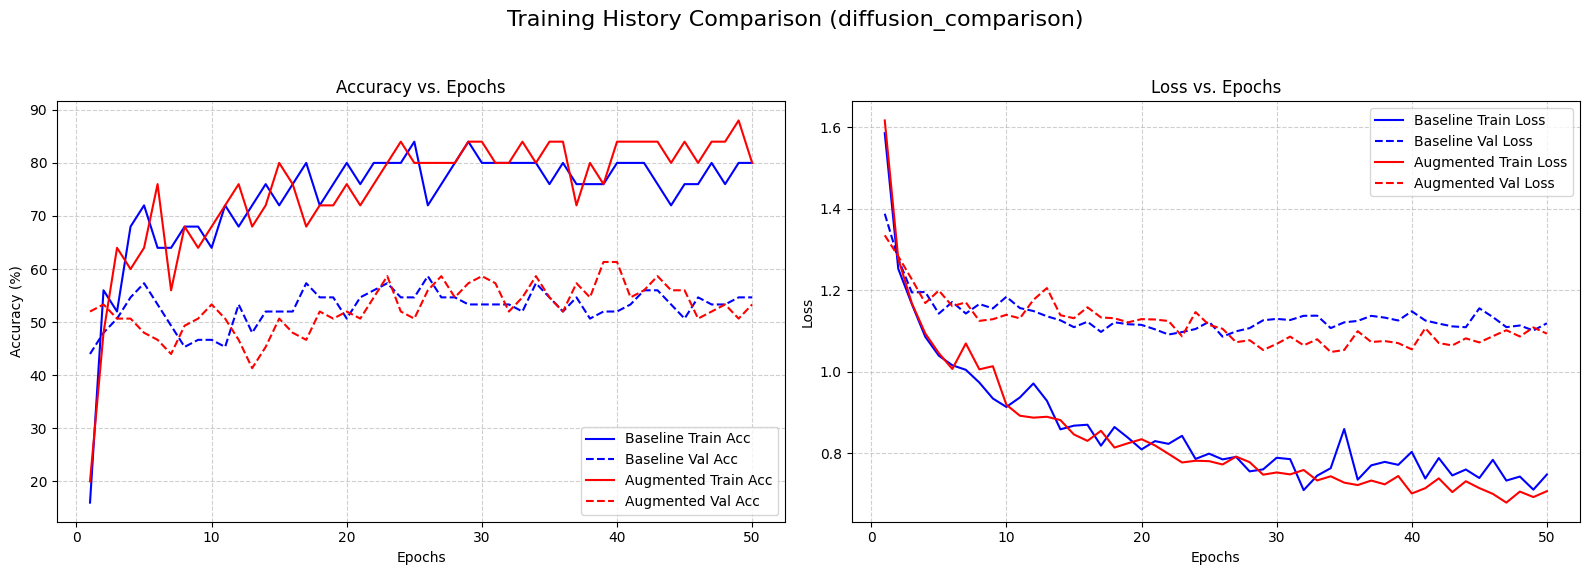

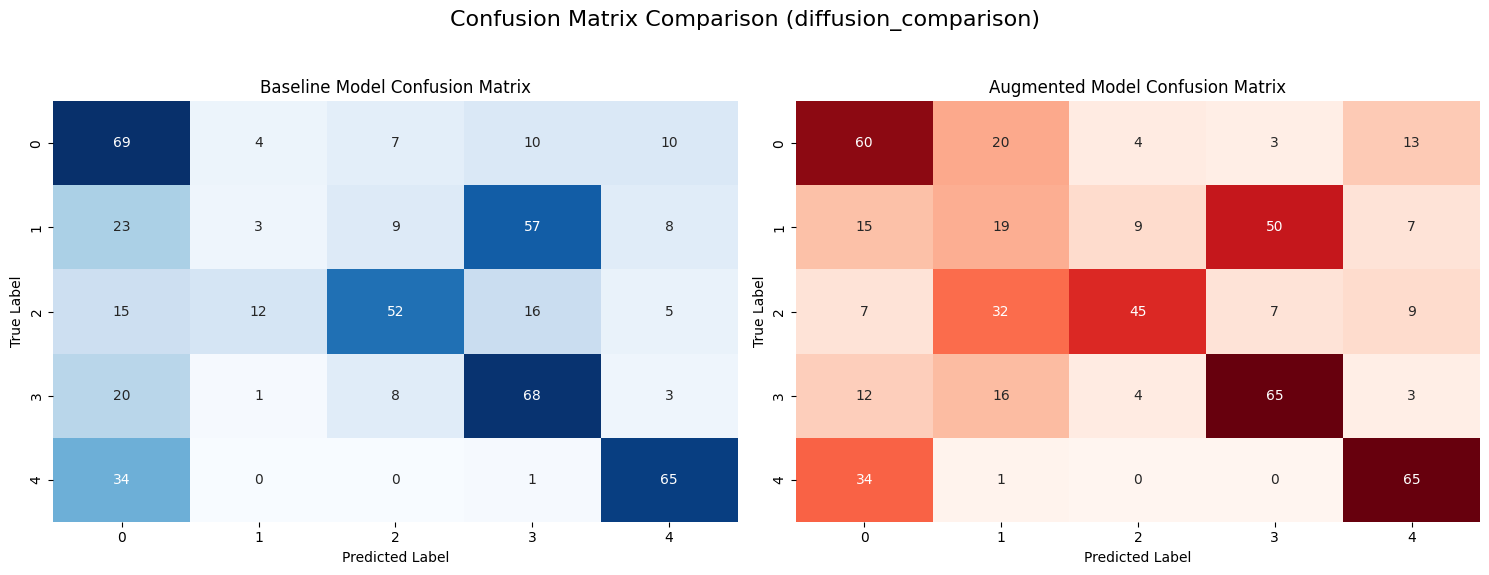


--- Test Accuracy Comparison (diffusion_comparison) ---
Baseline Model:  51.40%
Augmented Model: 50.80%
Absolute Improvement: -0.60%
Relative Improvement: -1.17%

--- Pipeline Finished ---

--------------------------------------------------------------------------------
Pipeline completed successfully in 11.17 minutes.
  Final Baseline Test Acc: 51.40%
  Final Augmented Test Acc: 50.80%
--------------------------------------------------------------------------------


In [15]:
# --- Main Execution Block ---
if __name__ == "__main__":
    print(f"Torch version: {torch.__version__}")
    print(f"CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"CUDA version: {torch.version.cuda}")
        print(f"Device name: {torch.cuda.get_device_name(0)}")

    start_time = time.time()
    results_dict = None
    try:
        # Run the main pipeline function
        results_dict = run_diffusion_augmentation_pipeline()

    except Exception as e:
        # Catch any top-level exceptions not caught within the pipeline
        print("\n" + "#" * 60)
        print(" UNCAUGHT EXCEPTION IN MAIN EXECUTION ")
        print("#" * 60)
        print(f"Error Type: {type(e).__name__}")
        print(f"Error Details: {e}")
        traceback.print_exc() # Print detailed traceback

    finally:
        # This block always runs, even if errors occur
        end_time = time.time()
        duration_minutes = (end_time - start_time) / 60
        print("\n" + "-" * 80)
        if results_dict is not None:
            print(f"Pipeline completed successfully in {duration_minutes:.2f} minutes.")
            # You could print key results from results_dict here
            if results_dict.get("baseline_metrics"):
                 print(f"  Final Baseline Test Acc: {results_dict['baseline_metrics'].get('test_accuracy', 'N/A'):.2f}%")
            if results_dict.get("augmented_metrics"):
                 print(f"  Final Augmented Test Acc: {results_dict['augmented_metrics'].get('test_accuracy', 'N/A'):.2f}%")
        else:
            print(f"Pipeline execution failed or was interrupted after {duration_minutes:.2f} minutes.")
        print("-" * 80)